# Interactive Sales Performance Dashboard for an Online Retail Store

**Module:** ACC102  
**Track:** Track 4 – Interactive Data Analysis Tool

## 1. Introduction

 This project analyses online retail transaction data and develops a small interactive dashboard for business decision-making. The target user is a small online store owner or store manager who wants to understand sales performance, product trends, and country-level sales patterns.

 The main analytical problem is:
 
 "How can an online retail store owner use historical transaction data to identify sales trends, top-selling products, and country-level sales patterns for better decision-making?"

 This project uses Python to load, clean, transform, and analyse transaction data. The final goal is to support the development of an interactive sales dashboard that communicates useful business insights.

## 2. Dataset Description

The dataset used in this project is the **Online Retail** dataset from the UCI Machine Learning Repository. It contains transaction-level data from a UK-based online retail business. The dataset includes invoice number, product code, product description, quantity, invoice date, unit price, customer ID, and country.

This dataset was selected because it is relevant to a business and retail context and provides detailed transaction data that is suitable for sales analysis. It also supports the development of a user-focused dashboard for monitoring store performance.

**Data source:** UCI Machine Learning Repository, Online Retail dataset  
**Access date:** 13 April 2026

## 3. Data Loading and Initial Inspection

In this section, the dataset is loaded into Python and basic inspection is carried out. This includes previewing the first few rows, creating a revenue variable, checking the size of the dataset, and identifying missing values.

In [1]:
# Import libraries for data analysis and visualisation
import pandas as pd
import matplotlib.pyplot as plt

# Load the Excel dataset
df = pd.read_excel("Online Retail.xlsx")

# Preview the first five rows
print(df.head())

  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

          InvoiceDate  UnitPrice  CustomerID         Country  
0 2010-12-01 08:26:00       2.55     17850.0  United Kingdom  
1 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
2 2010-12-01 08:26:00       2.75     17850.0  United Kingdom  
3 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
4 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  


In [2]:
# Create a new revenue column
df["Revenue"] = df["Quantity"] * df["UnitPrice"]

# Preview the new revenue values
print(df[["Quantity", "UnitPrice", "Revenue"]].head())

   Quantity  UnitPrice  Revenue
0         6       2.55    15.30
1         6       3.39    20.34
2         8       2.75    22.00
3         6       3.39    20.34
4         6       3.39    20.34


In [3]:
# Check the size of the dataset
print(df.shape)

# Check missing values in each column
print(df.isnull().sum())

(541909, 9)
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
Revenue             0
dtype: int64


### Initial Observations

The dataset was successfully loaded into Python. A new `Revenue` variable was created by multiplying `Quantity` by `UnitPrice`, because the dataset does not include a direct sales value column.

Initial inspection shows that the dataset contains 541,909 records and 9 variables after creating the revenue column. Missing values are mainly found in `Description` and `CustomerID`, which indicates that data cleaning is required before further analysis.

## 4. Data Cleaning

In this section, the dataset is cleaned to improve the reliability of the analysis. Cancelled transactions, invalid quantity and price records, and rows with missing product descriptions are removed before further analysis.

In [4]:
# Remove cancelled invoices
df = df[~df["InvoiceNo"].astype(str).str.startswith("C")]

# Remove rows with invalid quantity or unit price
df = df[(df["Quantity"] > 0) & (df["UnitPrice"] > 0)]

# Remove rows with missing product description
df = df.dropna(subset=["Description"])

# Check the cleaned dataset
print(df.shape)
print(df.isnull().sum())

(530104, 9)
InvoiceNo           0
StockCode           0
Description         0
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     132220
Country             0
Revenue             0
dtype: int64


### Cleaning Results

After cleaning, the dataset contained 530,104 records and 9 variables. Cancelled transactions, invalid quantity and price records, and rows with missing product descriptions were removed.

Most variables were complete after cleaning, while missing values remained mainly in `CustomerID`. This means that sales, product, and country-level analysis can be carried out reliably, but customer-related analysis should be interpreted more cautiously.

## 5. Feature Engineering and Monthly Sales Trend

 To support time-based sales analysis, additional variables are created from the transaction date. Monthly revenue is then calculated to identify overall sales trends over time.

In [5]:
# Create a year-month column
df["YearMonth"] = df["InvoiceDate"].dt.to_period("M").astype(str)

# Calculate monthly revenue
monthly_revenue = df.groupby("YearMonth")["Revenue"].sum().reset_index()

# Preview the monthly revenue table
print(monthly_revenue.head())

  YearMonth     Revenue
0   2010-12  823746.140
1   2011-01  691364.560
2   2011-02  523631.890
3   2011-03  717639.360
4   2011-04  537808.621


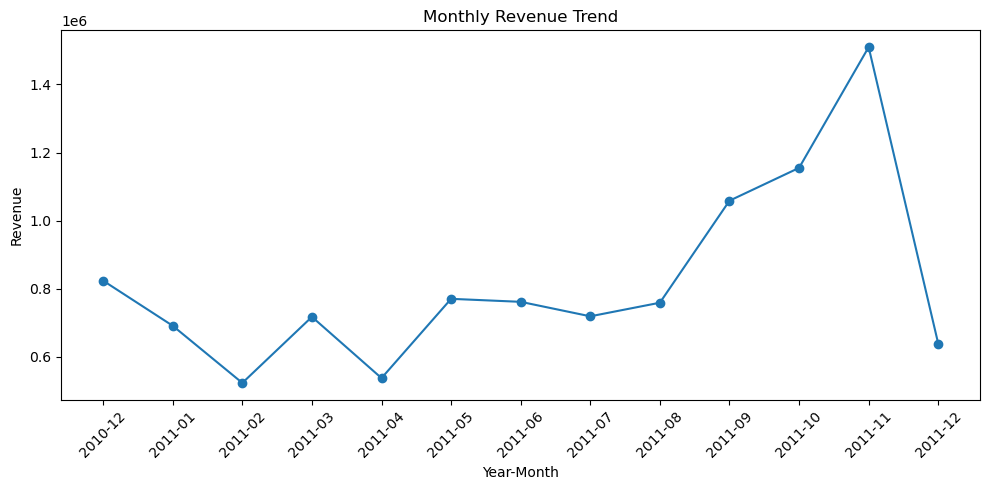

In [6]:
# Plot monthly revenue trend
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(monthly_revenue["YearMonth"], monthly_revenue["Revenue"], marker="o")
plt.xticks(rotation=45)
plt.title("Monthly Revenue Trend")
plt.xlabel("Year-Month")
plt.ylabel("Revenue")
plt.tight_layout()
plt.show()

### Monthly Revenue Trend
 The monthly revenue trend shows clear fluctuations over time. Revenue was relatively lower in the early months of 2011 and increased noticeably from August 2011 onwards. The highest revenue was recorded in November 2011, while December 2011 showed a sharp decline. However, this decline should be interpreted cautiously because the dataset only includes transactions up to 9 December 2011, meaning that the final month is incomplete.

## 6. Top Products by Revenue

In this section, the products with the highest total revenue are identified. This helps the store owner understand which items contribute most to overall sales performance.

In [7]:
# Calculate top 10 products by revenue
top_products = df.groupby("Description")["Revenue"].sum().sort_values(ascending=False).head(10)

# Print the top 10 products
print(top_products)

Description
DOTCOM POSTAGE                        206248.77
REGENCY CAKESTAND 3 TIER              174484.74
PAPER CRAFT , LITTLE BIRDIE           168469.60
WHITE HANGING HEART T-LIGHT HOLDER    106292.77
PARTY BUNTING                          99504.33
JUMBO BAG RED RETROSPOT                94340.05
MEDIUM CERAMIC TOP STORAGE JAR         81700.92
Manual                                 78112.82
POSTAGE                                78101.88
RABBIT NIGHT LIGHT                     66964.99
Name: Revenue, dtype: float64


### Top Product Results

The top revenue-generating items were identified from the cleaned dataset. Some items, such as `REGENCY CAKESTAND 3 TIER` and `WHITE HANGING HEART T-LIGHT HOLDER`, appear to be strong-performing products. However, some entries such as `DOTCOM POSTAGE` and `Manual` may represent non-product transaction categories, so they should be interpreted with caution.

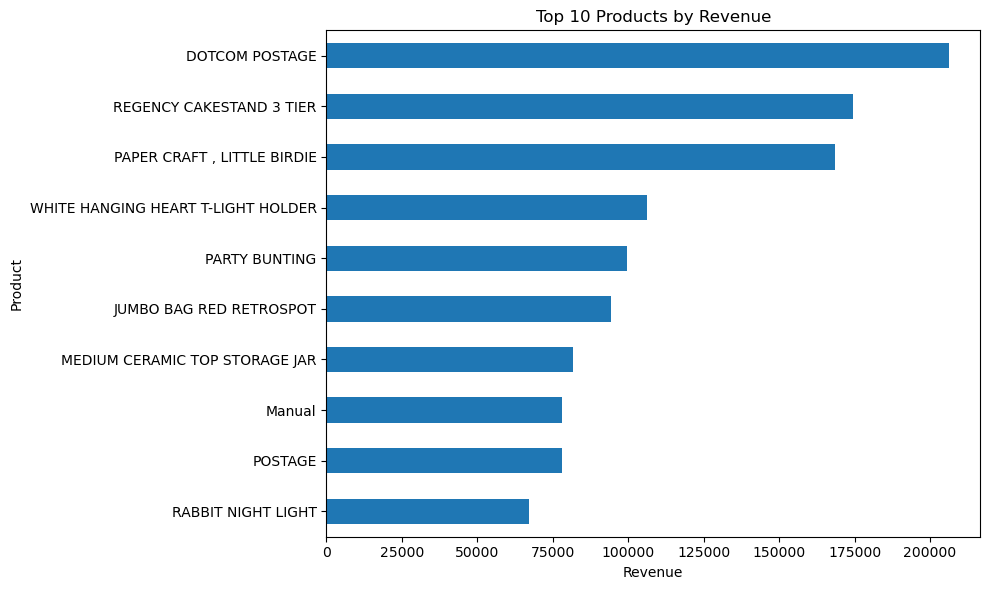

In [8]:
# Plot top 10 products by revenue
plt.figure(figsize=(10, 6))
top_products.sort_values().plot(kind="barh")
plt.title("Top 10 Products by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Product")
plt.tight_layout()
plt.show()

### Top Products by Revenue

The product revenue chart highlights which items contributed most to total sales. This can help a store owner focus on high-performing items, improve inventory planning, and support future sales strategies.

## 7. Country Analysis

This section examines revenue by country to identify which markets contributed most to overall sales performance.

In [9]:
# Calculate top 10 countries by revenue
top_countries = df.groupby("Country")["Revenue"].sum().sort_values(ascending=False).head(10)

# Print the top 10 countries
print(top_countries)

Country
United Kingdom    9025222.084
Netherlands        285446.340
EIRE               283453.960
Germany            228867.140
France             209715.110
Australia          138521.310
Spain               61577.110
Switzerland         57089.900
Belgium             41196.340
Sweden              38378.330
Name: Revenue, dtype: float64


### Country Analysis Results

The country-level analysis shows that the `United Kingdom` generated by far the highest revenue, making it the dominant market in the dataset. Other important markets included the `Netherlands`, `EIRE`, `Germany`, and `France`, although their revenue levels were much lower than that of the United Kingdom.

This suggests that the business was heavily dependent on the UK market, while international sales played a secondary but still meaningful role.

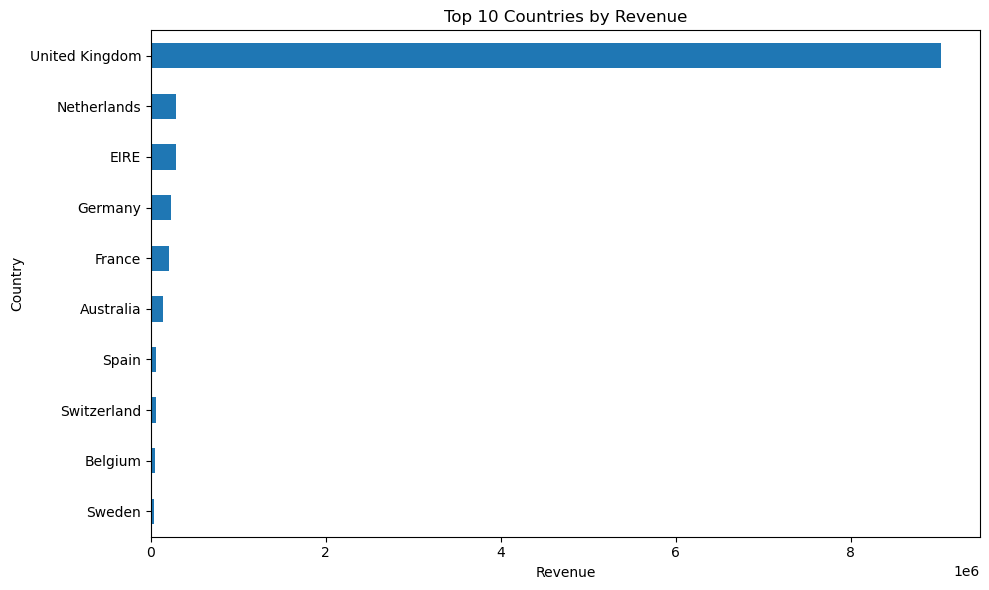

In [10]:
# Plot top 10 countries by revenue
plt.figure(figsize=(10, 6))
top_countries.sort_values().plot(kind="barh")
plt.title("Top 10 Countries by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Country")
plt.tight_layout()
plt.show()

### Revenue by Country

The country revenue chart shows a very strong concentration of sales in the `United Kingdom`, which generated far more revenue than any other country in the dataset. This suggests that the business was heavily dependent on its domestic market.

At the same time, several international markets, such as the `Netherlands`, `EIRE`, `Germany`, and `France`, also contributed to total revenue. However, because the `United Kingdom` dominates the distribution, the differences among the other countries are less visible in the chart.

## 8. Key Findings

- A new `Revenue` variable was created by multiplying `Quantity` by `UnitPrice`, which made direct sales analysis possible.
- After data cleaning, the dataset contained 530,104 valid transaction records.
- Monthly revenue fluctuated over time, with stronger performance observed from August to November 2011.
- November 2011 recorded the highest monthly revenue, while December 2011 should be interpreted cautiously because the month is incomplete in the dataset.
- Several high-revenue items were identified, including `REGENCY CAKESTAND 3 TIER` and `WHITE HANGING HEART T-LIGHT HOLDER`.
- The `United Kingdom` was the dominant market by revenue, far exceeding all other countries in the dataset.

## 9. Conclusion

This project analysed online retail transaction data and demonstrated how Python can be used to support business-oriented sales analysis. Through data loading, cleaning, transformation, and visualisation, the notebook identified sales trends, high-performing products, and country-level revenue patterns.

The results suggest that the business was strongly dependent on the `United Kingdom` market, while some products contributed particularly high revenue. The monthly trend analysis also showed that sales performance changed over time, with stronger results in the later months of 2011.

Overall, this notebook provides a useful analytical foundation for the development of an interactive sales dashboard for a small online retail store owner or manager.

## 10. Limitations

This analysis has several limitations. First, the dataset contains a large number of missing values in `CustomerID`, which limits customer-level analysis. Second, some entries such as `DOTCOM POSTAGE` and `Manual` may not represent standard products, so product results should be interpreted carefully. Third, the dataset ends on 9 December 2011, which means that the final month is incomplete and cannot be compared directly with full months.